# 二分类决策树完整示例（sklearn）

本 Notebook 使用 **Breast Cancer Wisconsin Diagnostic** 数据集，演示一个完整的二分类任务流程：

**读取数据 → 数据检查 → 特征与标签构造 → 训练/验证/测试划分 → 模型训练与调参 → 测试集评估 → 可视化**

---
请注意：运行前，请确认当前文件夹中已有数据文件 `wdbc.csv`


## 0. 数据集说明

本例使用 **Breast Cancer Wisconsin Diagnostic Dataset**（乳腺癌诊断数据集）。

数据文件 `wdbc.csv` 是一个**无表头**的 CSV 文件，共 32 列：

- 第 1 列：样本编号 `id`
- 第 2 列：诊断结果 `diagnosis`
  - `M`：恶性（malignant）
  - `B`：良性（benign）
- 第 3 列到第 32 列：30 个数值型特征，例如：
  - `radius_mean`
  - `texture_mean`
  - `perimeter_mean`
  - `area_mean`
  - `smoothness_mean`
  - `compactness_mean`
  - `concavity_mean`
  - `radius_worst`
  - `texture_worst`
  - `area_worst`
  - ......

为了方便建模，本 Notebook 会额外生成一个数值标签列：

- `target = 1` 表示恶性
- `target = 0` 表示良性

> 说明：这里把恶性样本设为正类。


## 1. 导入必要库


In [31]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42
DATA_PATH = Path("wdbc.csv")
WDBC_COLUMNS = ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## 2. 读取数据

这里使用 `pd.read_csv()` 读取本地 CSV。

注意：`wdbc.csv` 是**无表头**文件，因此读取时要显式指定 `header=None` 和列名列表。  


In [32]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"找不到数据文件：{DATA_PATH}\n"
        "请把 wdbc.csv 与本 Notebook 放在同一个文件夹中。"
    )

# 原始 wdbc.csv 没有表头，因此这里需要手动指定列名
df = pd.read_csv(DATA_PATH, header=None, names=WDBC_COLUMNS)

# 新增数值标签列：1=malignant（恶性），0=benign（良性）
df["target"] = df["diagnosis"].map({"M": 1, "B": 0})

print("数据规模：", df.shape)
df.head()


数据规模： (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,target
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. 数据检查

在正式建模前，先做三件事：

1. 查看字段名称  
2. 检查是否有缺失值  
3. 查看标签分布  

这是一个很重要的习惯。后面做 bank 实验时，也建议先做同样的检查。


In [33]:
print("字段名称：")
print(df.columns.tolist())

print("\n缺失值统计：")
missing_count = df.isnull().sum()
print(missing_count[missing_count > 0])

print("\n标签分布：")
print(df["diagnosis"].value_counts())


字段名称：
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'target']

缺失值统计：
Series([], dtype: int64)

标签分布：
diagnosis
B    357
M    212
Name: count, dtype: int64


## 4. 标签分布可视化

分类任务里，先观察两类样本数量是否平衡。  
如果类别非常不均衡，那么不能只看 Accuracy，还要重点看 Precision、Recall 和 F1-score。


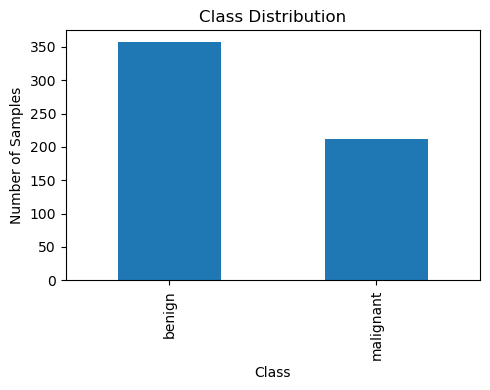

In [34]:
class_count = df["diagnosis"].value_counts().reindex(["B", "M"])
class_count.index = ["benign", "malignant"]

plt.figure(figsize=(5, 4))
class_count.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=200)
plt.show()


## 5. 构造特征 `X` 和标签 `y`

这里做一个最基本的数据预处理：

- `id` 只是样本编号，不参与建模
- `diagnosis` 是原始文字标签，已经在前面转成了target，不参与建模
- `target` 是数值标签，作为模型预测目标
- 其余 30 列作为特征


In [35]:
X = df.drop(columns=["id", "diagnosis", "target"])
y = df["target"]

print("特征矩阵 X：", X.shape)
print("标签 y：", y.shape)
X.head()


特征矩阵 X： (569, 30)
标签 y： (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 6. 划分训练集、验证集和测试集

这里把数据分成三部分：

- **训练集**：训练模型
- **验证集**：比较不同参数
- **测试集**：最后一次性评估模型

注意：

- 测试集不应该参与调参
- 先在验证集上比较模型，确定参数后，再在测试集上做最终评估


In [36]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,   # 最终约为 60% / 20% / 20%
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print(f"训练集: {X_train.shape[0]} 条")
print(f"验证集: {X_val.shape[0]} 条")
print(f"测试集: {X_test.shape[0]} 条")


训练集: 341 条
验证集: 114 条
测试集: 114 条


## 7. 决策树建模：比较 3 组参数

在实际建模中，我们通常不会只训练 1 个模型，而是会比较不同参数设置下的结果，从而选择更合适的模型。


在比较不同参数之前，可以先了解 **欠拟合、适度拟合和过拟合** 的含义：

- **欠拟合**：模型过于简单，不能充分学习数据中的规律。通常表现为训练集和测试集上的效果都不理想。
- **适度拟合**：模型能够较好地学习数据特征，同时在测试集上也有较稳定的表现，说明模型具有较好的泛化能力。
- **过拟合**：模型过于复杂，对训练数据学习得过于充分，甚至把噪声也“记住”了。通常表现为训练集效果很好，但测试集效果明显下降。



本例重点关注以下参数：

- `criterion`：划分准则，常用 `gini` 或 `entropy`
- `max_depth`：树的最大深度，用来控制模型复杂度
- `min_samples_split`：一个节点继续分裂所需的最小样本数
- `min_samples_leaf`：叶子节点中包含的最少样本数

在本例中，我们将通过比较 3 组决策树参数，观察模型复杂度变化对结果的影响。常见的调整方式包括：

| 参数 | 如果模型欠拟合 | 如果模型过拟合 |
|------|----------------|----------------|
| `max_depth` | 适当**增大**，让树更深，增强模型表达能力 | 适当**减小**，限制树深度，防止模型过于复杂 |
| `min_samples_split` | 适当**减小**，让节点更容易继续分裂 | 适当**增大**，提高分裂条件，抑制树继续生长 |
| `min_samples_leaf` | 适当**减小**，允许叶子节点保留更少样本 | 适当**增大**，避免叶子节点样本过少，降低过拟合风险 |
| `criterion` | 可尝试比较 `gini` 与 `entropy`，选择表现更好的划分准则 | 可尝试比较 `gini` 与 `entropy`，选择泛化效果更好的划分准则 |



In [37]:
param_list = [
    {
        "name": "Model_A_gini_depth3",
        "criterion": "gini",
        "max_depth": 3,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "name": "Model_B_entropy_depth4",
        "criterion": "entropy",
        "max_depth": 4,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "name": "Model_C_entropy_depth5_leaf5",
        "criterion": "entropy",
        "max_depth": 5,
        "min_samples_split": 4,
        "min_samples_leaf": 5,
    },
]

results = []

for params in param_list:
    clf = DecisionTreeClassifier(
        criterion=params["criterion"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=RANDOM_STATE,
    )

    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    results.append({
        "model": params["name"],
        "criterion": params["criterion"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, pos_label=1),
        "recall": recall_score(y_val, y_val_pred, pos_label=1),
        "f1": f1_score(y_val, y_val_pred, pos_label=1),
    })

results_df = pd.DataFrame(results)
results_df


,model,criterion,max_depth,min_samples_split,min_samples_leaf,accuracy,precision,recall,f1
0,Model_A_gini_depth3,gini,3,2,1,0.921053,0.904762,0.883721,0.894118
1,Model_B_entropy_depth4,entropy,4,2,1,0.903509,0.833333,0.930233,0.879121
2,Model_C_entropy_depth5_leaf5,entropy,5,4,5,0.938596,0.891304,0.953488,0.921348


## 8. 选择较优模型

在比较多个模型时，不能只看一个指标，还需要结合分类任务中的多种评价指标进行综合分析。  
本例以验证集上的 **F1-score** 作为主要选择依据，同时结合混淆矩阵、Accuracy、Precision 和 Recall 来理解模型效果。

### 1. 混淆矩阵（Confusion Matrix）

混淆矩阵用于展示分类结果与真实标签之间的对应关系。在二分类任务中，通常可写成：

|                | 预测为正类 | 预测为负类 |
|----------------|------------|------------|
| 真实为正类     | TP         | FN         |
| 真实为负类     | FP         | TN         |

其中：

- **TP（True Positive）**：真实为正类，预测也为正类
- **TN（True Negative）**：真实为负类，预测也为负类
- **FP（False Positive）**：真实为负类，却预测成正类
- **FN（False Negative）**：真实为正类，却预测成负类

混淆矩阵可以帮助我们直观地看到：  
模型到底是“分错了多少”，以及“错在什么地方”。

---

### 2. 本例为什么选择 F1-score 作为主要依据？

在本例中，我们希望模型不仅有较好的整体分类效果，还能够兼顾 **Precision** 和 **Recall**。  
因此，这里以验证集上的 **F1-score** 作为选择较优模型的主要依据。

同时，也建议结合混淆矩阵和其他评价指标一起分析，这样对模型效果的判断会更加全面。

In [38]:
best_row = results_df.sort_values(by="f1", ascending=False).iloc[0]
best_model_name = best_row["model"]

print("选择的模型：", best_model_name)
best_row


选择的模型： Model_C_entropy_depth5_leaf5


model                Model_C_entropy_depth5_leaf5
criterion                                 entropy
max_depth                                       5
min_samples_split                               4
min_samples_leaf                                5
accuracy                                 0.938596
precision                                0.891304
recall                                   0.953488
f1                                       0.921348
Name: 2, dtype: object

## 9. 用最佳参数重新训练最终模型

参数选定后，可以把训练集和验证集合并，重新训练一个最终模型，  
然后只在测试集上做一次最终评估。


In [39]:
best_params = next(p for p in param_list if p["name"] == best_model_name)

final_clf = DecisionTreeClassifier(
    criterion=best_params["criterion"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=RANDOM_STATE,
)

final_clf.fit(X_train_val, y_train_val)


,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 10. 测试集评估

本示例中，`target=1` 表示恶性，因此这些指标默认重点关注“恶性”这一类。


In [40]:
y_test_pred = final_clf.predict(X_test)

print("测试集最终评估结果：")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, pos_label=1):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred, pos_label=1):.4f}")

print("\n分类报告：")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["benign", "malignant"],
))


测试集最终评估结果：
Accuracy : 0.9649
Precision: 1.0000
Recall   : 0.9048
F1-score : 0.9500

分类报告：
              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## 11. 混淆矩阵

混淆矩阵能帮助我们看清楚：

- 哪些样本被分对了
- 哪些样本被误判了
- 错误主要发生在哪一类上

关注到混淆矩阵左下角的数值，说明有 4 个恶性样本被错判成良性


[[72  0]
 [ 4 38]]


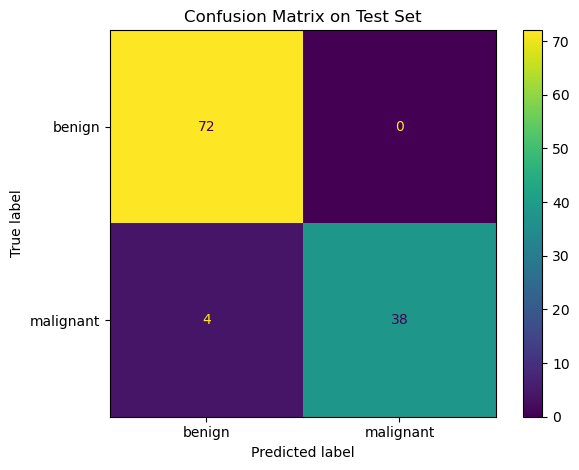

In [41]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["benign", "malignant"],
)
disp.plot()
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()


## 12. 特征重要性

决策树可以输出各特征的重要性。  
这有助于理解：模型更依赖哪些变量做分类判断。


In [42]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_clf.feature_importances_,
}).sort_values(by="importance", ascending=False)

print("以下是模型中最重要的 5 个特征，重要性数值越大，说明该特征对分类判断的贡献越大：")
feature_importance.head(5)


以下是模型中最重要的 5 个特征，重要性数值越大，说明该特征对分类判断的贡献越大：


,feature,importance
22,perimeter_worst,0.660564
27,concave_points_worst,0.112575
7,concave_points_mean,0.084995
21,texture_worst,0.070730
13,area_se,0.046466


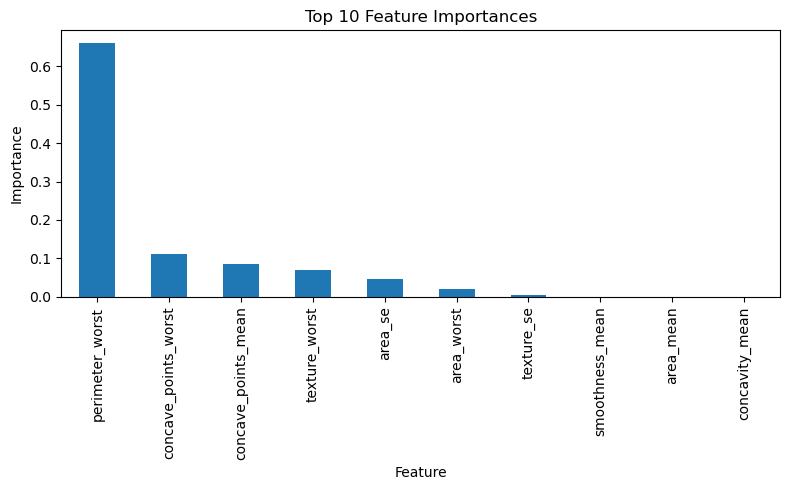

In [43]:
plt.figure(figsize=(8, 5))
feature_importance.head(10).set_index("feature")["importance"].plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_top10.png", dpi=200)
plt.show()


## 13. 决策树可视化

如果树太深，整张图会非常拥挤。  
这里通过 `max_depth=3` 限制展示深度，只画出前几层，便于观察主要决策路径。


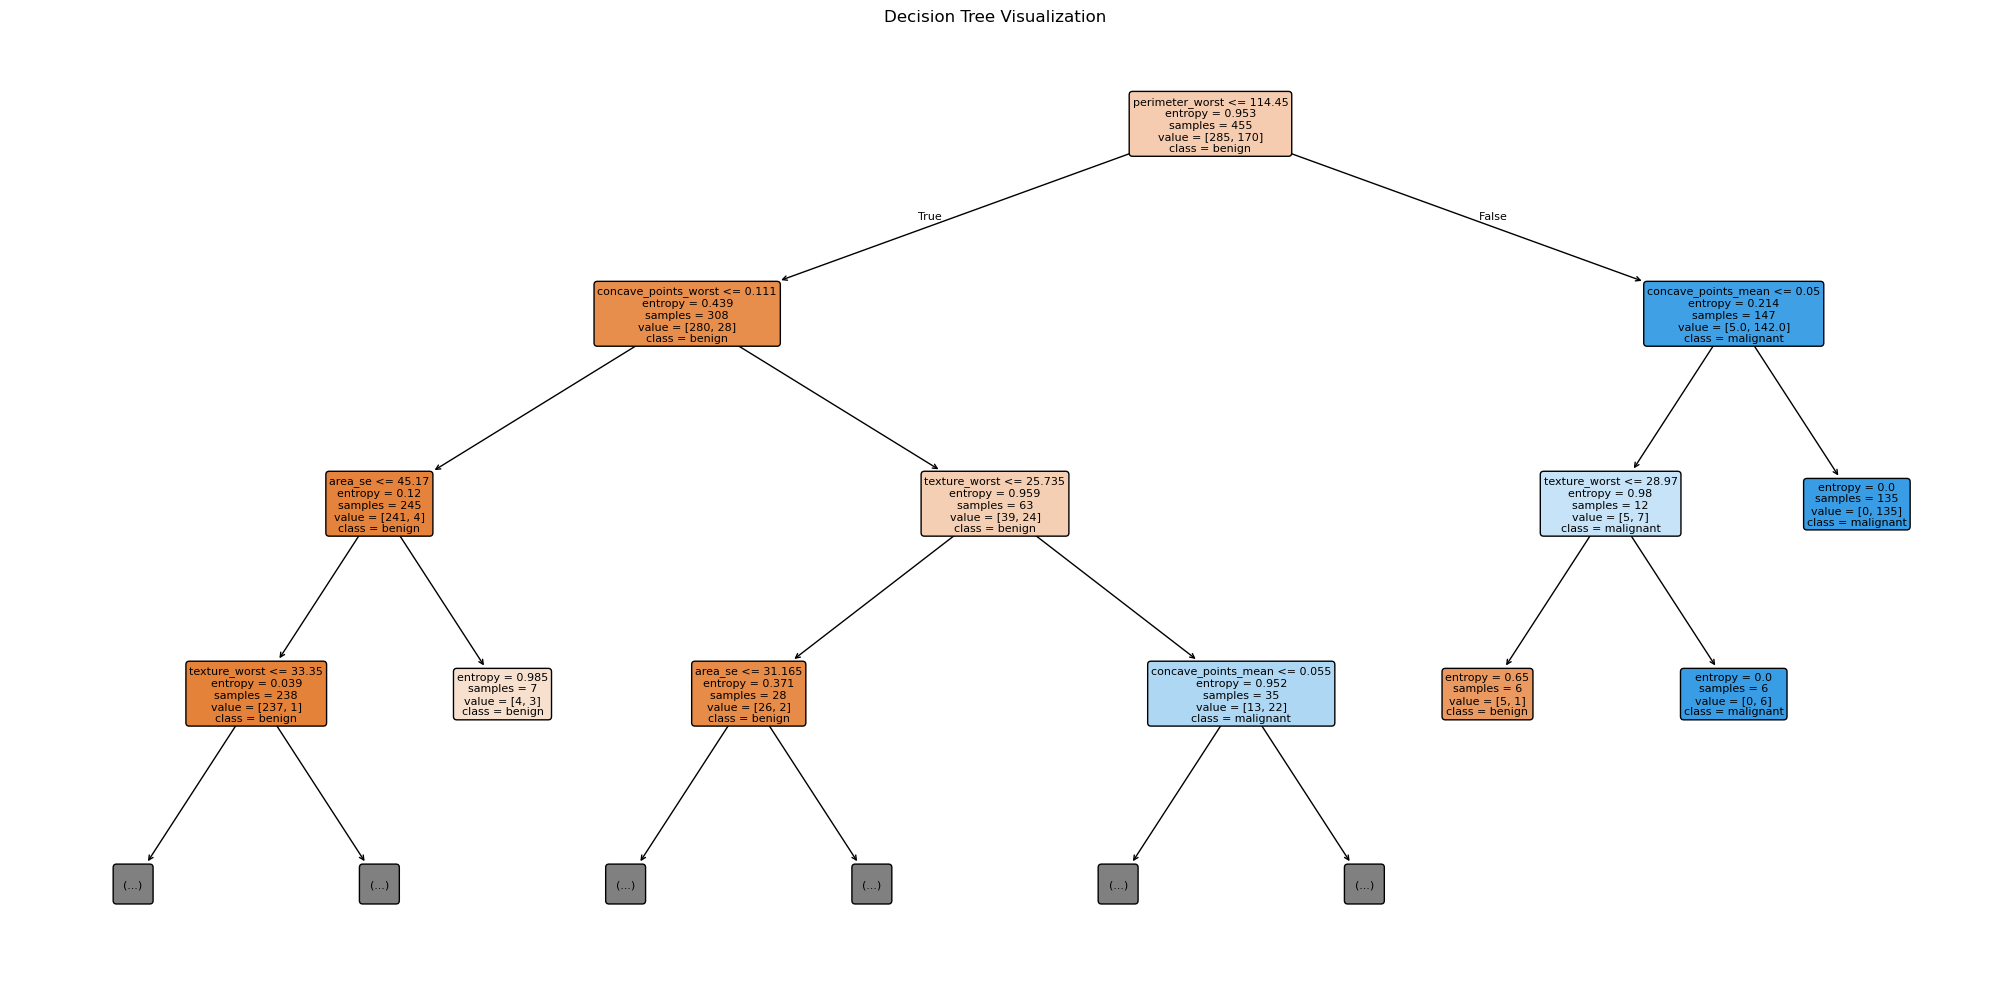

In [44]:
plt.figure(figsize=(20, 10))
plot_tree(
    final_clf,
    feature_names=X.columns,
    class_names=["benign", "malignant"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=200)
plt.show()


## 14. 这个完整示例想让你掌握什么？

做完这个 Notebook，希望你能明确 `sklearn` 做分类任务的一般流程：

1. 读入本地数据
2. 检查数据
3. 构造特征和标签
4. 划分训练/验证/测试集
5. 设置模型参数并比较结果
6. 在测试集上评估模型
7. 用混淆矩阵、特征重要性、决策树图辅助分析

这个流程之后可以迁移到正式实验中的 `bank_train.csv / bank_test.csv`。
